In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
#pivot table:-(it takes column-wise data as input and provide summary of data in 2D dataframe) 

#builtin dataset from seaborn
df=sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
#find average bill paid on the basis of gender and smoker

df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()

total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [5]:
df.pivot_table(index='sex',columns='smoker',values='total_bill')

smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [6]:
df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='count')

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


In [8]:
df.pivot_table(index='sex',columns='smoker',aggfunc='count')

day     size     time     tip     total_bill    
smoker Yes  No  Yes  No  Yes  No Yes  No        Yes  No
sex                                                    
Male    60  97   60  97   60  97  60  97         60  97
Female  33  54   33  54   33  54  33  54         33  54

In [ ]:
df.pivot_table(index=['sex','smoker'],columns=['day','time'],values='total_bill')#it will gives average

day                 Thur               Fri                Sat        Sun
time               Lunch Dinner      Lunch  Dinner     Dinner     Dinner
sex    smoker                                                           
Male   Yes     19.171000    NaN  11.386667  25.892  21.837778  26.141333
       No      18.486500    NaN        NaN  17.475  19.929063  20.403256
Female Yes     19.218571    NaN  13.260000  12.200  20.266667  16.540000
       No      15.899167  18.78  15.980000  22.750  19.003846  20.824286

In [10]:
df.pivot_table(index=['sex','smoker'],columns=['day','time'],aggfunc={'size':'mean','tip':'max','total_bill':'sum'})

size                                               tip  \
day                Thur              Fri              Sat       Sun  Thur   
time              Lunch Dinner     Lunch Dinner    Dinner    Dinner Lunch   
sex    smoker                                                               
Male   Yes     2.300000    NaN  1.666667    2.4  2.629630  2.600000  5.00   
       No      2.500000    NaN       NaN    2.0  2.656250  2.883721  6.70   
Female Yes     2.428571    NaN  2.000000    2.0  2.200000  2.500000  5.00   
       No      2.500000    2.0  3.000000    2.0  2.307692  3.071429  5.17   

                                                total_bill                \
day                    Fri           Sat    Sun       Thur           Fri   
time          Dinner Lunch Dinner Dinner Dinner      Lunch Dinner  Lunch   
sex    smoker                                                              
Male   Yes       NaN  2.20   4.73  10.00    6.5     191.71    NaN  34.16   
       No        NaN   NaN   3.50   9.00    6.0     369.73    NaN    NaN   
Female Yes       NaN  3.48   4.30   6.50    4.0     134.53    NaN  39.78   
       No        3.0  3.00   3.25   4.67    5.2     381.58  18.78  15.98   

                                       
day                       Sat     Sun  
time           Dinner  Dinner  Dinner  
sex    smoker                          
Male   Yes     129.46  589.62  392.12  
       No       34.95  637.73  877.34  
Female Yes      48.80  304.00   66.16  
       No       22.75  247.05  291.54

In [ ]:
#margins
df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum',margins=True)#calculate total

smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


In [14]:
#plotting graph
df=pd.read_csv('../3Datasets/expense_data.csv')
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [ ]:
#expense in each category monthwise
df['Category'].value_counts()

Category
Food                156
Other                60
Transportation       31
Apparel               7
Household             6
Allowance             6
Social Life           5
Education             1
Salary                1
Self-development      1
Beauty                1
Gift                  1
Petty cash            1
Name: count, dtype: int64

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    str    
 1   Account         277 non-null    str    
 2   Category        277 non-null    str    
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    str    
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    str    
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    str    
 10  Account.1       277 non-null    float64
dtypes: float64(5), str(6)
memory usage: 23.9 KB


In [17]:
df['Date']=pd.to_datetime(df['Date'])
df['Date']

0     2022-03-02 10:11:00
1     2022-03-02 10:11:00
2     2022-03-01 19:50:00
3     2022-03-01 18:56:00
4     2022-03-01 18:22:00
              ...        
272   2021-11-22 14:16:00
273   2021-11-22 14:16:00
274   2021-11-21 17:07:00
275   2021-11-21 15:50:00
276   2021-11-21 13:30:00
Name: Date, Length: 277, dtype: datetime64[us]

In [19]:
df['month']=df['Date'].dt.month_name()
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March


In [22]:
data=df.pivot_table(index='month',columns='Category',values='INR',aggfunc='sum',fill_value=0)
data

Category,Allowance,Apparel,Beauty,Education,Food,Gift,Household,Other,Petty cash,Salary,Self-development,Social Life,Transportation
month,,,,,,,,,,,,,
December,11000.0,2590.0,196.0,0.0,6440.72,0.0,4800.0,1790.0,0.0,0.0,400.0,513.72,914.0
February,0.0,798.0,0.0,0.0,5579.85,0.0,2808.0,20000.0,0.0,0.0,0.0,1800.00,5078.8
January,1000.0,0.0,0.0,1400.0,9112.51,0.0,4580.0,13178.0,0.0,8000.0,0.0,200.00,2850.0
March,0.0,0.0,0.0,0.0,195.00,0.0,0.0,900.0,0.0,0.0,0.0,0.00,30.0
November,2000.0,0.0,0.0,0.0,3174.40,115.0,0.0,2000.0,3.0,0.0,0.0,0.00,331.0


<Axes: xlabel='month'>

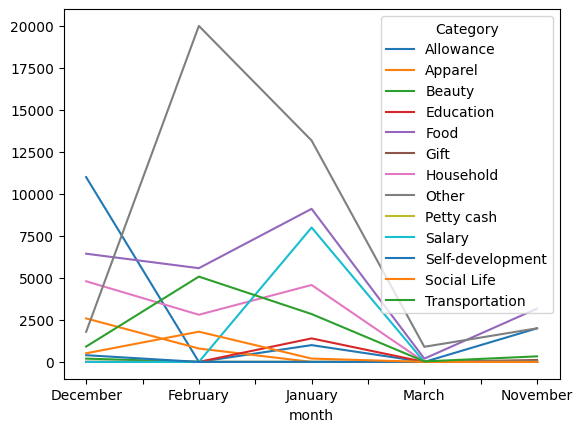

In [23]:
data.plot()

<Axes: xlabel='month'>

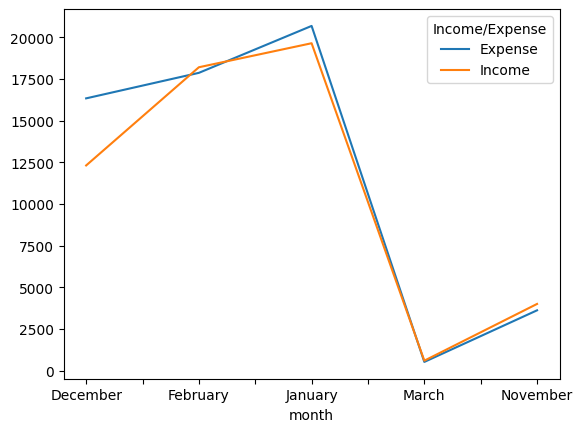

In [25]:
df.pivot_table(index='month',columns='Income/Expense',values='INR',aggfunc='sum',fill_value=0).plot()

<Axes: xlabel='month'>

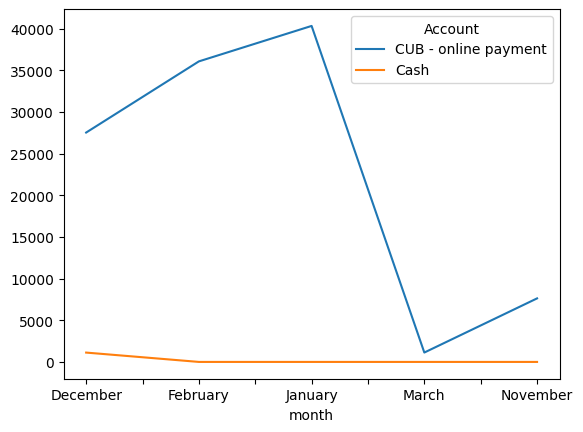

In [27]:
df.pivot_table(index='month',columns='Account',values='INR',aggfunc='sum',fill_value=0).plot()

In [28]:
import numpy as np
import pandas as pd

In [ ]:
#vectorized operations
a=np.array([1,2,3,4])
a*4 #apply on all elements of array

array([ 4,  8, 12, 16])

In [30]:
#problem with vectorized operations
s=['cat','mat',None,'rat']
[i.startswith('c') for i in s]

AttributeError: 'NoneType' object has no attribute 'startswith'

In [ ]:
#how pandas solve this issue
s=pd.Series(['cat','mat',None,'rat'])
#string accessor
s.str.startswith('c') #fast and  optimized

0     True
1    False
2    False
3    False
dtype: bool

In [49]:
df=pd.read_csv('../3Datasets/titanic.csv')
df['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

In [33]:
#lower/upper/capitalize/title
df['Name'].str.upper()

0                                BRAUND, MR. OWEN HARRIS
1      CUMINGS, MRS. JOHN BRADLEY (FLORENCE BRIGGS TH...
2                                 HEIKKINEN, MISS. LAINA
3           FUTRELLE, MRS. JACQUES HEATH (LILY MAY PEEL)
4                               ALLEN, MR. WILLIAM HENRY
                             ...                        
886                                MONTVILA, REV. JUOZAS
887                         GRAHAM, MISS. MARGARET EDITH
888             JOHNSTON, MISS. CATHERINE HELEN "CARRIE"
889                                BEHR, MR. KARL HOWELL
890                                  DOOLEY, MR. PATRICK
Name: Name, Length: 891, dtype: str

In [34]:
df['Name'].str.capitalize()

0                                Braund, mr. owen harris
1      Cumings, mrs. john bradley (florence briggs th...
2                                 Heikkinen, miss. laina
3           Futrelle, mrs. jacques heath (lily may peel)
4                               Allen, mr. william henry
                             ...                        
886                                Montvila, rev. juozas
887                         Graham, miss. margaret edith
888             Johnston, miss. catherine helen "carrie"
889                                Behr, mr. karl howell
890                                  Dooley, mr. patrick
Name: Name, Length: 891, dtype: str

In [35]:
#to count character in name of person
df['Name'].str.len()

0      23
1      51
2      22
3      44
4      24
       ..
886    21
887    28
888    40
889    21
890    19
Name: Name, Length: 891, dtype: int64

In [36]:
df['Name'][df['Name'].str.len()==82].values[0]

'Penasco y Castellana, Mrs. Victor de Satode (Maria Josefa Perez de Soto y Vallejo)'

In [ ]:
"           Mathematics  is  the Topper's Tools      ".strip() #remove start and end space

"Mathematics  is  the Topper's Tools"

In [43]:
df['Name'].str.split(',').str.get(0)

0         Braund
1        Cumings
2      Heikkinen
3       Futrelle
4          Allen
         ...    
886     Montvila
887       Graham
888     Johnston
889         Behr
890       Dooley
Name: Name, Length: 891, dtype: object

In [52]:
df[df['Name'].str.contains('john',case=False)].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
41,42,0,2,"Turpin, Mrs. William John Robert (Dorothy Ann ...",female,27.0,1,0,11668,21.0000,NaN,S
45,46,0,3,"Rogers, Mr. William John",male,NaN,0,0,S.C./A.4. 23567,8.0500,NaN,S
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,34.0,0,1,231919,23.0000,NaN,S


In [55]:
# find names with start char is consonant and end char vowel
df[df['Name'].str.contains('^[^aeiouAEIOU].+[^aeiouAEIOU]$')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
#Timestamp Objects of pandas:- (it refers a particular moment in time)

import numpy as np
import pandas as pd



In [ ]:
#creating a timestamp
pd.Timestamp('2026/04/21')#YY-MM-DD

Timestamp('2026-04-21 00:00:00')

In [58]:
#variations
pd.Timestamp('2026-4-21')

Timestamp('2026-04-21 00:00:00')

In [60]:
pd.Timestamp('2026')

Timestamp('2026-01-01 00:00:00')

In [61]:
pd.Timestamp('21st April 2026')

Timestamp('2026-04-21 00:00:00')

In [66]:
pd.Timestamp('2026-04-21 16:11')#Option 1 (24-hour format)

Timestamp('2026-04-21 16:11:00')

In [67]:
pd.Timestamp('21 April 2026 04:11 PM')#Option 1 (12-hour format)

Timestamp('2026-04-21 16:11:00')

In [ ]:
#Using Datetime Object in python
import datetime as dt

dt.datetime(2026,4,21,16,15)

datetime.datetime(2026, 4, 21, 16, 15)

In [70]:
x=pd.Timestamp(dt.datetime(2026,4,21,16,15))
x

Timestamp('2026-04-21 16:15:00')

In [71]:
#fetching attributes

x.year

2026

In [72]:
x.month

4

In [73]:
x.day

21

In [ ]:
x.hour
#'datetime'  of pythonn takes large time than pandas 'timestamp'

16

In [75]:
# why separate objects to handle data and time when python already has datetime functionality?

In [76]:
#The weaknesses of Python's datetime format inspired the NumPy team to add a set of native time series data type to NumPy.
#The datetime64 dtype encodes dates as 64-bit integers, and thus allows arrays of dates to be represented very compactly.

In [77]:
import numpy as np
date = np.array('2015-07-04', dtype=np.datetime64)
date

array('2015-07-04', dtype='datetime64[D]')

In [ ]:
date + np.arange(12)
#Because of the uniform type in NumPy datetime64 arrays, this type of operation can be accomplished much more quickly than if we were working directly with Python's datetime objects, especially as arrays get large
#Pandas Timestamp object combines the ease-of-use of python datetime with the efficient storage and vectorized interface of numpy.datetime64
#From a group of these Timestamp objects, Pandas can construct a DatetimeIndex that can be used to index data in a Series or DataFrame

array(['2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07',
       '2015-07-08', '2015-07-09', '2015-07-10', '2015-07-11',
       '2015-07-12', '2015-07-13', '2015-07-14', '2015-07-15'],
      dtype='datetime64[D]')

In [80]:
#datetimeIndex is used to store multiple dates
# from strings
type(pd.DatetimeIndex(['2023/1/1','2022/1/1','2021/1/1']))

pandas.DatetimeIndex

In [81]:
# using python datetime object
pd.DatetimeIndex([dt.datetime(2023,1,1),dt.datetime(2022,1,1),dt.datetime(2021,1,1)])

DatetimeIndex(['2023-01-01', '2022-01-01', '2021-01-01'], dtype='datetime64[us]', freq=None)

In [83]:
# using pd.timestamps
dt_index = pd.DatetimeIndex([pd.Timestamp(2023,1,1),pd.Timestamp(2022,1,1),pd.Timestamp(2021,1,1)])

In [84]:
# using datatimeindex as series index

pd.Series([1,2,3],index=dt_index)

2023-01-01    1
2022-01-01    2
2021-01-01    3
dtype: int64

In [86]:
# generate daily dates in a given range
pd.date_range(start='2023/1/5',end='2023/2/28',freq='D')

DatetimeIndex(['2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
               '2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24',
               '2023-01-25', '2023-01-26', '2023-01-27', '2023-01-28',
               '2023-01-29', '2023-01-30', '2023-01-31', '2023-02-01',
               '2023-02-02', '2023-02-03', '2023-02-04', '2023-02-05',
               '2023-02-06', '2023-02-07', '2023-02-08', '2023-02-09',
               '2023-02-10', '2023-02-11', '2023-02-12', '2023-02-13',
               '2023-02-14', '2023-02-15', '2023-02-16', '2023-02-17',
               '2023-02-18', '2023-02-19', '2023-02-20', '2023-02-21',
               '2023-02-22', '2023-02-23', '2023-02-24', '2023-02-25',
               '2023-02-26', '2023-02-27', '2023-02-28'],
              dtype

In [87]:
# generate alternate 3rd  dates  in a given range
pd.date_range(start='2023/1/5',end='2023/2/28',freq='3D')

DatetimeIndex(['2023-01-05', '2023-01-08', '2023-01-11', '2023-01-14',
               '2023-01-17', '2023-01-20', '2023-01-23', '2023-01-26',
               '2023-01-29', '2023-02-01', '2023-02-04', '2023-02-07',
               '2023-02-10', '2023-02-13', '2023-02-16', '2023-02-19',
               '2023-02-22', '2023-02-25', '2023-02-28'],
              dtype='datetime64[us]', freq='3D')

In [88]:
#B-Buisness days(sat,sun is not there)
pd.date_range(start='2026/4/21',end='2026/5/28',freq='B')

DatetimeIndex(['2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24',
               '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30',
               '2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06',
               '2026-05-07', '2026-05-08', '2026-05-11', '2026-05-12',
               '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18',
               '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22',
               '2026-05-25', '2026-05-26', '2026-05-27', '2026-05-28'],
              dtype='datetime64[us]', freq='B')

In [93]:
#W->one day per week
pd.date_range(start='2026/4/21',end='2026/5/28',freq='W-THU')

DatetimeIndex(['2026-04-23', '2026-04-30', '2026-05-07', '2026-05-14',
               '2026-05-21', '2026-05-28'],
              dtype='datetime64[us]', freq='W-THU')

In [ ]:
#MS->month start
pd.date_range(start='2026/4/21',end='2026/5/28',freq='MS')

DatetimeIndex(['2026-05-01'], dtype='datetime64[us]', freq='MS')

In [97]:
pd.date_range(start='2026/4/21',periods=25,freq='h')

DatetimeIndex(['2026-04-21 00:00:00', '2026-04-21 01:00:00',
               '2026-04-21 02:00:00', '2026-04-21 03:00:00',
               '2026-04-21 04:00:00', '2026-04-21 05:00:00',
               '2026-04-21 06:00:00', '2026-04-21 07:00:00',
               '2026-04-21 08:00:00', '2026-04-21 09:00:00',
               '2026-04-21 10:00:00', '2026-04-21 11:00:00',
               '2026-04-21 12:00:00', '2026-04-21 13:00:00',
               '2026-04-21 14:00:00', '2026-04-21 15:00:00',
               '2026-04-21 16:00:00', '2026-04-21 17:00:00',
               '2026-04-21 18:00:00', '2026-04-21 19:00:00',
               '2026-04-21 20:00:00', '2026-04-21 21:00:00',
               '2026-04-21 22:00:00', '2026-04-21 23:00:00',
               '2026-04-22 00:00:00'],
              dtype='datetime64[us]', freq='h')

In [98]:
#to_datetime()

# simple series example
s = pd.Series(['2023/1/1','2022/1/1','2021/1/1'])
pd.to_datetime(s).dt.day_name()

0      Sunday
1    Saturday
2      Friday
dtype: str

In [99]:
# with errors
s = pd.Series(['2023/1/1','2022/1/1','2021/130/1'])
pd.to_datetime(s,errors='coerce').dt.month_name()

0    January
1    January
2        NaN
dtype: str

In [101]:
df = pd.read_csv('../3Datasets/expense_data.csv')
df.shape

(277, 11)

In [102]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [104]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[us]
 1   Account         277 non-null    str           
 2   Category        277 non-null    str           
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    str           
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    str           
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    str           
 10  Account.1       277 non-null    float64       
dtypes: datetime64[us](1), float64(5), str(5)
memory usage: 23.9 KB


In [105]:
#dt accessor (properties of series value)

df['Date'].dt.is_quarter_start

0      False
1      False
2      False
3      False
4      False
       ...  
272    False
273    False
274    False
275    False
276    False
Name: Date, Length: 277, dtype: bool

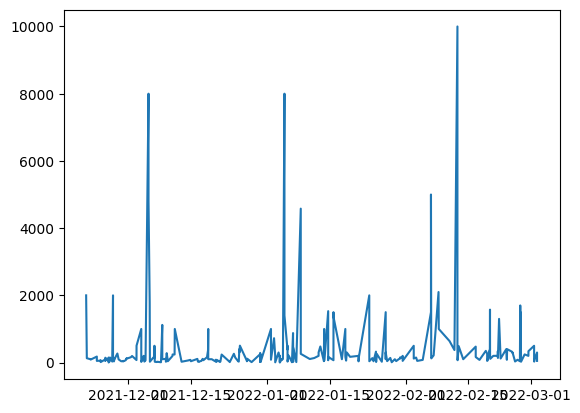

In [106]:
# plot graph
import matplotlib.pyplot as plt
plt.plot(df['Date'],df['INR'])

<Axes: xlabel='day_name'>

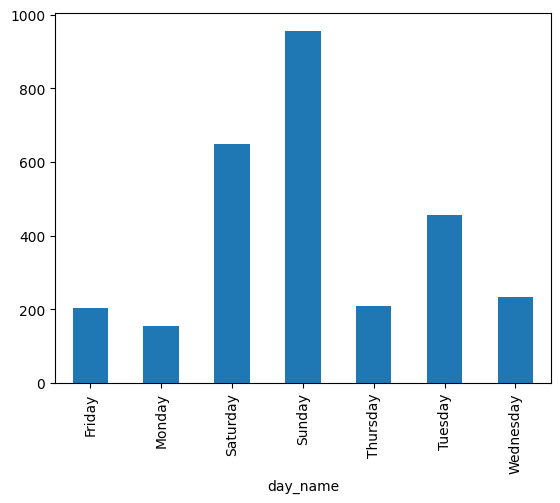

In [107]:
# day name wise bar chart/month wise bar chart

df['day_name'] = df['Date'].dt.day_name()

df.groupby('day_name')['INR'].mean().plot(kind='bar')

<Axes: xlabel='month_name'>

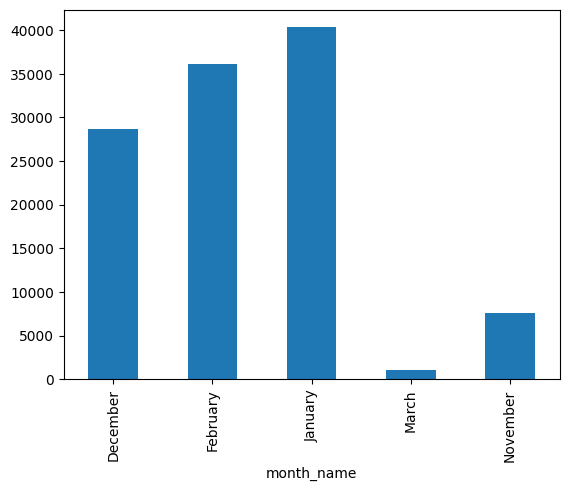

In [111]:
df['month_name'] = df['Date'].dt.month_name()
df.groupby('month_name')['INR'].sum().plot(kind='bar')

<Axes: >

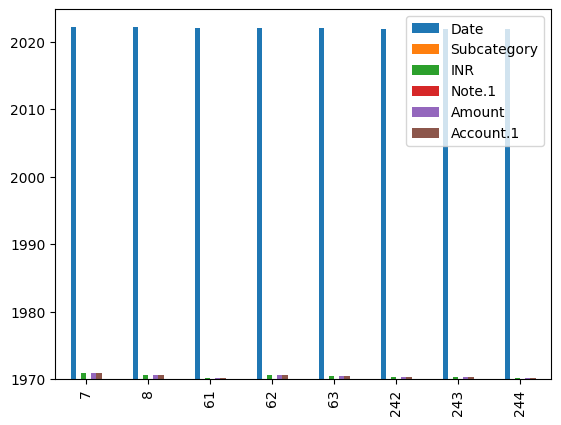

In [113]:
df[df['Date'].dt.is_month_end].plot(kind='bar')

In [114]:
#Datetime library in detail with current date
import datetime as dt
dt.date.today()

datetime.date(2026, 4, 21)

In [115]:
dt.date.today().strftime('%Y')

'2026'

In [116]:
dt.date.today().strftime('%B')

'April'

In [ ]:
dt.date.today().strftime('%d')#day no. of the month

'21'

In [ ]:
dt.date.today().strftime('%W') #week number of year

'16'

In [ ]:
dt.date.today().strftime('%w')#weekday number of current week

'2'

In [ ]:
dt.date.today().strftime('%j') #day number of the year

'111'

In [ ]:
dt.date.today().strftime('%A') #day name of the week

'Tuesday'

In [123]:
from datetime import datetime

now = datetime.now()
print(now)

2026-04-21 16:54:38.378565


In [124]:
now.date()

datetime.date(2026, 4, 21)

In [127]:
dt = datetime(2026, 4, 21, 16, 30) #create custom date
dt

datetime.datetime(2026, 4, 21, 16, 30)

In [128]:
datetime.strptime("21-04-2026", "%d-%m-%Y")#String → Date (Parsing)

datetime.datetime(2026, 4, 21, 0, 0)

In [129]:
now.strftime("%d-%m-%Y %H:%M")#Date → String (Formatting)

'21-04-2026 16:54'

In [131]:
from datetime import timedelta

future = now + timedelta(days=5)
past   = now - timedelta(hours=3)
past

datetime.datetime(2026, 4, 21, 13, 54, 38, 378565)

In [135]:
from datetime import datetime, timezone
import zoneinfo

utc_time = datetime.now(timezone.utc)

local_time = utc_time.astimezone(zoneinfo.ZoneInfo("Asia/Kolkata"))
local_time


datetime.datetime(2026, 4, 21, 16, 59, 11, 707125, tzinfo=zoneinfo.ZoneInfo(key='Asia/Kolkata'))